In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import io # Input/Output Module
import os # OS interfaces
import cv2 # OpenCV package
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import math

from urllib import request # module for opening HTTP requests
from matplotlib import pyplot as plt # Plotting library
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading
import hashlib, pickle
import inspect
import shutil
from sklearn.model_selection import train_test_split
from face_detection import DNNFaceDetector, HAARPreprocessor, run_preprocessing
from visualize import (
    plot_class_distribution, plot_class_grid, plot_face_debug,
    plot_image_sequence, plot_hog_features, plot_tsne,
    plot_eigenfaces, plot_explained_variance, plot_pca_reconstruction,
    plot_pca_scatter, plot_validation_images, plot_confusion_matrix,
)
from preprocessing import (convert_crops_to_gray, extract_hog_batch,
                            get_train_val_split, summarize_dataset)
from preprocessing import flatten_images, normalize_per_image, apply_pca
from preprocessing import face_to_gray

<div style="width:100%; height:140px">
    <img src="https://www.kuleuven.be/iportfolio/images/logos/kuleuven.png/@@images/image-800-e89431243530c6a800aa1186b9f6891b.png" width = auto, heigh = 200px align=left>
</div>


KUL H02A5a Computer Vision: Group Assignment 1
---------------------------------------------------------------
<div style="height:50px"></div>

<span style="color:red">Team 27></span>

<span style="color:red">**TODO**: Change the notebook name by replacing the X with your actual group number.</span>

Student names: <span style="color:red"> Fosteris Emmanouil, Paschalidis Marios, Greiner Luc, Reyes Salazar Jose, Digenis Stefanos</span>.

The goal of this assignment is to explore more advanced techniques for constructing features that better describe objects of interest and to perform face recognition using these features. This assignment will be delivered in groups of 5 (either composed by you or randomly assigned by your TA's).

---------------------------------------------------------------
This notebook is structured as follows:

0. Data loading & Preprocessing
1. Feature Representations
2. Evaluation Metrics 
3. Classifiers
4. Experiments
5. Publishing best results
6. Discussion

Make sure that your notebook is **self-contained** and **fully documented**. Provide strong arguments for the design choices that you made and what insights you got from your experiments. Make use of the *Group assignment 1* forum/discussion board on Toledo if you have any questions.

Good luck! 


<div class="alert alert-block alert-info">
<b>NOTE:</b> This notebook is just a example/template, feel free to adjust in any way you please! Just keep things organised and document accordingly!
</div>

<div class="alert alert-block alert-info">
<b>NOTE:</b> Clearly indicate the improvements that you make!!! You can for instance use titles like: <i>3.1. Improvement: Non-linear SVM with RBF Kernel.<i>
</div>
    
---------------------------------------------------------------
# 0. Data loading & Preprocessing

## 0.1. Loading data
The training set is many times smaller than the test set and this might strike you as odd, however, this is close to a real world scenario where your system might be put through daily use! In this session we will try to do the best we can with the data that we've got! 

In [2]:
# Input data files are available in the read-only "../input/" directory

train = pd.read_csv(
    'datasets/train_set.csv', index_col = 0)
train.index = train.index.rename('id')

test = pd.read_csv(
    'datasets/test_set.csv', index_col = 0)
test.index = test.index.rename('id')

# read the images as numpy arrays and store in "img" column
train['img'] = [cv2.cvtColor(np.load('datasets/train/train_{}.npy'.format(index), allow_pickle=False), cv2.COLOR_BGR2RGB) 
                for index, row in train.iterrows()]

test['img'] = [cv2.cvtColor(np.load('datasets/test/test_{}.npy'.format(index), allow_pickle=False), cv2.COLOR_BGR2RGB) 
                for index, row in test.iterrows()]
  

train_size, test_size = len(train),len(test)

"The training set contains {} examples, the test set contains {} examples.".format(train_size, test_size)

'The training set contains 80 examples, the test set contains 1816 examples.'

*Note: this dataset is a subset of the* [*VGG face dataset*](https://www.robots.ox.ac.uk/~vgg/data/vgg_face/).

## 0.2. A first look
Let's have a look at the data columns and class distribution.

Note that **Jesse is assigned the classification label 1**, and **Mila is assigned the classification label 2**. The dataset also contains 20 images of **look alikes (assigned classification label 0)** and the raw images. 

## 0.3. Preprocess data
### 0.3.1 Example: HAAR face detector
In this example we use the [HAAR feature based cascade classifiers](https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_objdetect/py_face_detection/py_face_detection.html) to detect faces, then the faces are resized so that they all have the same shape. If there are multiple faces in an image, we only take the first one. 

<div class="alert alert-block alert-info"> <b>NOTE:</b> You can write temporary files to <code>/kaggle/temp/</code> or <code>../../tmp</code>, but they won't be saved outside of the current session
</div>


In [3]:
FACE_SIZE  = (100, 100)
CLASS_NAMES  = {0: "Michael/Sarah", 1: "Jesse", 2: "Mila"}

# Recommended: DNN with caching — skips reprocessing on subsequent runs
train_X_dnn, train_y_dnn, test_X_dnn = run_preprocessing(
    train, test,
    detector   = "dnn",       # or "haar" to compare
    face_size  = FACE_SIZE,
    model_path = "tmp",
    cache_path = "dnn_prepped_data"   # set to None to always reprocess
)

train_X_haar, train_y_haar, test_X_haar = run_preprocessing(
    train, test,
    detector   = "haar",      # or "dnn" to compare
    face_size  = FACE_SIZE,
    model_path = "tmp",
    cache_path = "haar_prepped_data"  # set to None to always reprocess
)

Loading cached arrays from 'dnn_prepped_data' ...
  train_X: (80, 100, 100, 3)  train_y: (80,)  test_X: (1816, 100, 100, 3)
Loading cached arrays from 'haar_prepped_data' ...
  train_X: (80, 100, 100, 3)  train_y: (80,)  test_X: (1816, 100, 100, 3)


In [4]:
# plot_face_debug(train, train_X_dnn, train_y_dnn, class_id=1)
# plot_face_debug(train, train_X_dnn, train_y_dnn, class_id=1)
# plot_face_debug(train, train_X_dnn, train_y_dnn, class_id=1)

Now we are ready to rock!

# 1. Feature Representations

In [5]:
class IdentityFeatureExtractor:
    """A simple function that returns the input"""
    
    def transform(self, X):
        return X
    
    def __call__(self, X):
        return self.transform(X)

## 1.1. Baseline 1: HOG feature extractor/Scale Invariant Feature Transform

In [ ]:
from skimage.feature import hog

class HOGFeatureExtractor(IdentityFeatureExtractor):
    """
    HOG feature extractor that accepts either:
      - a raw face crop (float32 RGB 100x100) from the face detector
      - an already-converted grayscale image

    Internally uses face_to_gray for the conversion so there is a single
    code path for grayscale conversion — no duplication with preprocessing.py.
    """

    def __init__(
        self,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        target_size=(64, 64),
    ):
        self.target_size = target_size
        self.params = {
            "orientations":   orientations,
            "pixels_per_cell": pixels_per_cell,
            "cells_per_block": cells_per_block,
            "block_norm":     "L2-Hys",
            "visualize":      False,
        }

    def transform(self, img_array: np.ndarray) -> np.ndarray:
        """
        Extracts HOG features from a single image.

        Accepts color (H, W, 3) or grayscale (H, W) input of any dtype.
        face_to_gray handles: NaN sentinel → zeros, color → gray,
        float → uint8, resize to target_size.
        """
        if img_array.ndim == 2:
            # Already grayscale — still run through face_to_gray
            # to ensure correct size and dtype
            gray = face_to_gray(
                img_array[:, :, np.newaxis].repeat(3, axis=2).astype(np.float32),
                target_size=self.target_size,
            )
        else:
            # Color crop — full face_to_gray pipeline
            gray = face_to_gray(img_array, target_size=self.target_size)

        return hog(gray, **self.params).astype(np.float32)

### 1.1.1. t-SNE Plots
...

### 1.1.2. Discussion
...

## 1.2. Baseline 2: PCA feature extractor
...

In [8]:
class PCAFeatureExtractor(IdentityFeatureExtractor):
    """TODO: this feature extractor is under construction"""
    
    def __init__(self, n_components):
        self.n_components = n_components
        
    def transform(self, X):
        raise NotImplmentedError
        
    def inverse_transform(self, X):
        raise NotImplmentedError

### 1.2.1. Eigenface Plots
...

### 1.2.2. Feature Space Plots
...

### 1.2.3. Discussion
...

# 2. Evaluation Metrics
## 2.0. Example: Accuracy
As example metric we take the accuracy. Informally, accuracy is the proportion of correct predictions over the total amount of predictions. It is used a lot in classification but it certainly has its disadvantages...

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 3. Classifiers
## 3.0. Example: The *'not so smart'* classifier
This random classifier is not very complicated. It makes predictions at random, based on the distribution obseved in the training set. **It thus assumes** that the class labels of the test set will be distributed similarly to the training set.

In [10]:
class RandomClassificationModel:
    """Random classifier, draws a random sample based on class distribution observed 
    during training."""
    
    def fit(self, X, y):
        """Adjusts the class ratio instance variable to the one observed in y. 

        Parameters
        ----------
        X : tensor
            Training set
        y : array
            Training set labels

        Returns
        -------
        self : RandomClassificationModel
        """
        
        self.classes, self.class_ratio = np.unique(y, return_counts=True)
        self.class_ratio = self.class_ratio / self.class_ratio.sum()
        return self
        
    def predict(self, X):
        """Samples labels for the input data. 

        Parameters
        ----------
        X : tensor
            dataset
            
        Returns
        -------
        y_star : array
            'Predicted' labels
        """

        np.random.seed(0)
        return np.random.choice(self.classes, size = X.shape[0], p=self.class_ratio)
    
    def __call__(self, X):
        return self.predict(X)
    

## 3.1. Baseline 1: My favorite classifier
...

In [11]:
from sklearn.svm import LinearSVC

In [12]:
class FavoriteClassificationModel:
    """TODO: this classifier is under construction."""
    
    def fit(self, X, y):
        raise NotImplmentedError
        
    def predict(self, X):
        raise NotImplmentedError

# 4. Experiments
<div class="alert alert-block alert-info"> <b>NOTE:</b> Do <i>NOT</i> use this section to keep track of every little change you make in your code! Instead, highlight the most important findings and the major (best) pipelines that you've discovered.  
</div>
<br>

## 4.0. Example: basic pipeline
The basic pipeline takes any input and samples a label based on the class label distribution of the training set. As expected the performance is very poor, predicting approximately 1/4 correctly on the training set. There is a lot of room for improvement but this is left to you ;). 

In [13]:
feature_extractor = IdentityFeatureExtractor() 
classifier = RandomClassificationModel()

# train the model on the features
classifier.fit(feature_extractor(train_X_dnn), train_y_dnn)

# model/final pipeline
model = lambda X: classifier(feature_extractor(X))

In [14]:
# evaluate performance of the model on the training set
train_y_star = model(train_X_dnn)

"The performance on the training set is {:.2f}. This however, does not tell us much about the actual performance (generalisability).".format(
    accuracy_score(train_y_dnn, train_y_star))

'The performance on the training set is 0.26. This however, does not tell us much about the actual performance (generalisability).'

In [15]:
# predict the labels for the test set 
test_y_star = model(test_X_dnn)

In [16]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

In [17]:
def preprocess_face_crop(img_array):
    """Converts an already-cropped face to grayscale 64x64 for HOG."""
    if len(img_array.shape) == 3:
        img_gray = cv2.cvtColor(img_array.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img_array.astype(np.uint8)
    return cv2.resize(img_gray, TARGET_SIZE, interpolation=cv2.INTER_AREA)

In [18]:
extractor = HOGFeatureExtractor(
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2)
)

In [19]:
train_faces_gray = np.array([face_to_gray(img) for img in train_X_dnn])
test_faces_gray  = np.array([face_to_gray(img) for img in test_X_dnn])

In [20]:
print("\nExtracting HOG features...")
train_hog_features = np.array([extractor.transform(img) for img in train_faces_gray])
test_hog_features  = np.array([extractor.transform(img) for img in test_faces_gray])
print(f"HOG feature vector length: {train_hog_features.shape[1]}")  # 1764
print(f"Train HOG shape: {train_hog_features.shape}")               # (80, 1764)


Extracting HOG features...
HOG feature vector length: 1764
Train HOG shape: (80, 1764)


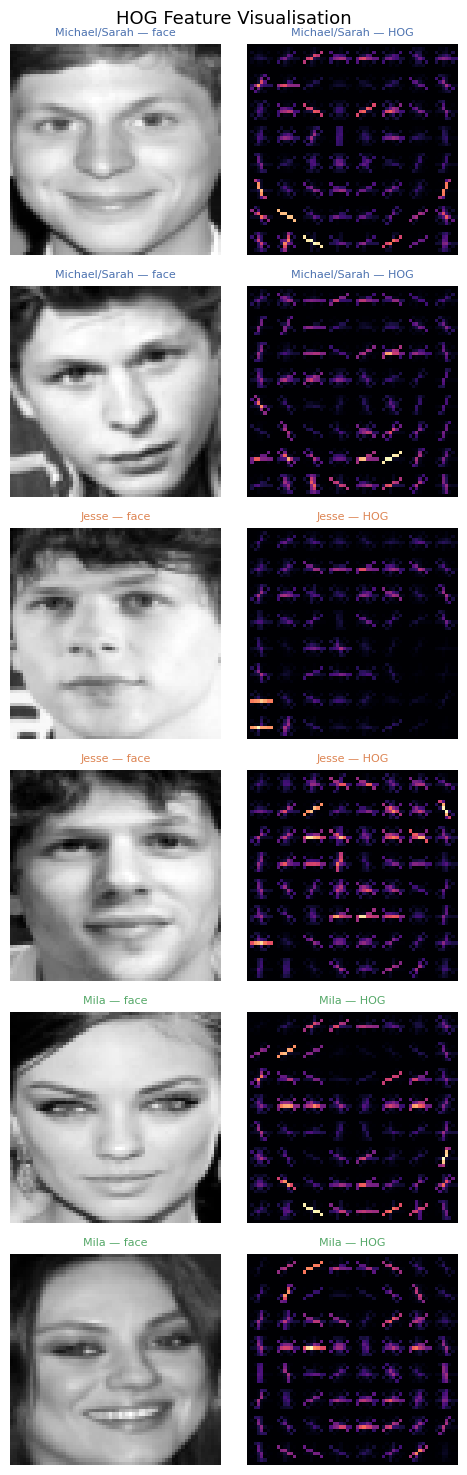

In [21]:
plot_hog_features(
    face_array=train_faces_gray,
    label_array=train_y_dnn,
    hog_params=extractor.params,   # reuse exact same params — no duplication
    n_per_class=2,
    class_names=CLASS_NAMES
)

Running t-SNE (perplexity=10) on (80, 1764) ...


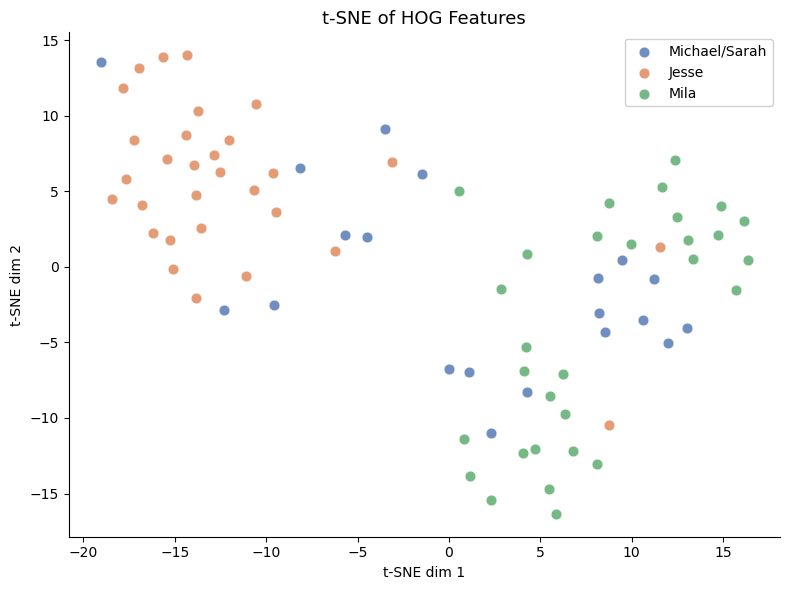

In [22]:
plot_tsne(
    features=train_hog_features,
    label_array=train_y_dnn,
    title="t-SNE of HOG Features",
    class_names=CLASS_NAMES,
    perplexity=10      # keep low — only 80 training samples
)

In [31]:
indices = np.arange(len(train_hog_features))
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.10,
    random_state=42,
    stratify=train_y_dnn
)

X_train = train_hog_features[train_idx]
X_val   = train_hog_features[val_idx]
y_train = train_y_dnn[train_idx]
y_val   = train_y_dnn[val_idx]

# Keep gray images aligned for later visualisation
X_val_gray = train_faces_gray[val_idx]

In [32]:
print(f"\nSplit: {len(X_train)} train / {len(X_val)} val")
print(f"Class distribution — train: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Class distribution — val:   {dict(zip(*np.unique(y_val, return_counts=True)))}")


Split: 72 train / 8 val
Class distribution — train: {np.int64(0): np.int64(18), np.int64(1): np.int64(27), np.int64(2): np.int64(27)}
Class distribution — val:   {np.int64(0): np.int64(2), np.int64(1): np.int64(3), np.int64(2): np.int64(3)}


In [33]:
hog_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', random_state=42, probability=True))
])

In [34]:
param_grid = {
    'svm__C':     [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.001, 0.01]
}

In [35]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [36]:
print("\nRunning GridSearchCV (5-fold CV on training split)...")
grid_search = GridSearchCV(
    hog_pipeline,
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\nBest params:    {grid_search.best_params_}")
print(f"Best CV acc:    {grid_search.best_score_*100:.1f}%")

best_model = grid_search.best_estimator_


Running GridSearchCV (5-fold CV on training split)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits



Best params:    {'svm__C': 10, 'svm__gamma': 'scale'}
Best CV acc:    72.3%



Validation Accuracy: 87.5%

Per-class breakdown:
               precision    recall  f1-score   support

Michael/Sarah       1.00      0.50      0.67         2
        Jesse       0.75      1.00      0.86         3
         Mila       1.00      1.00      1.00         3

     accuracy                           0.88         8
    macro avg       0.92      0.83      0.84         8
 weighted avg       0.91      0.88      0.86         8



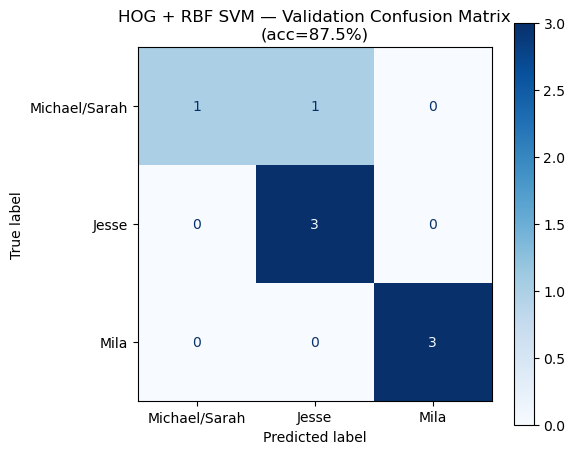

In [37]:
y_val_pred = best_model.predict(X_val)
val_acc    = accuracy_score(y_val, y_val_pred)

print(f"\n{'='*50}")
print(f"Validation Accuracy: {val_acc*100:.1f}%")
print(f"{'='*50}\n")
print("Per-class breakdown:")
print(classification_report(
    y_val, y_val_pred,
    target_names=['Michael/Sarah', 'Jesse', 'Mila']
))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred,
    display_labels=['Michael/Sarah', 'Jesse', 'Mila'],
    cmap='Blues',
    ax=ax
)
ax.set_title(f'HOG + RBF SVM — Validation Confusion Matrix\n(acc={val_acc*100:.1f}%)')
plt.tight_layout()
plt.show()

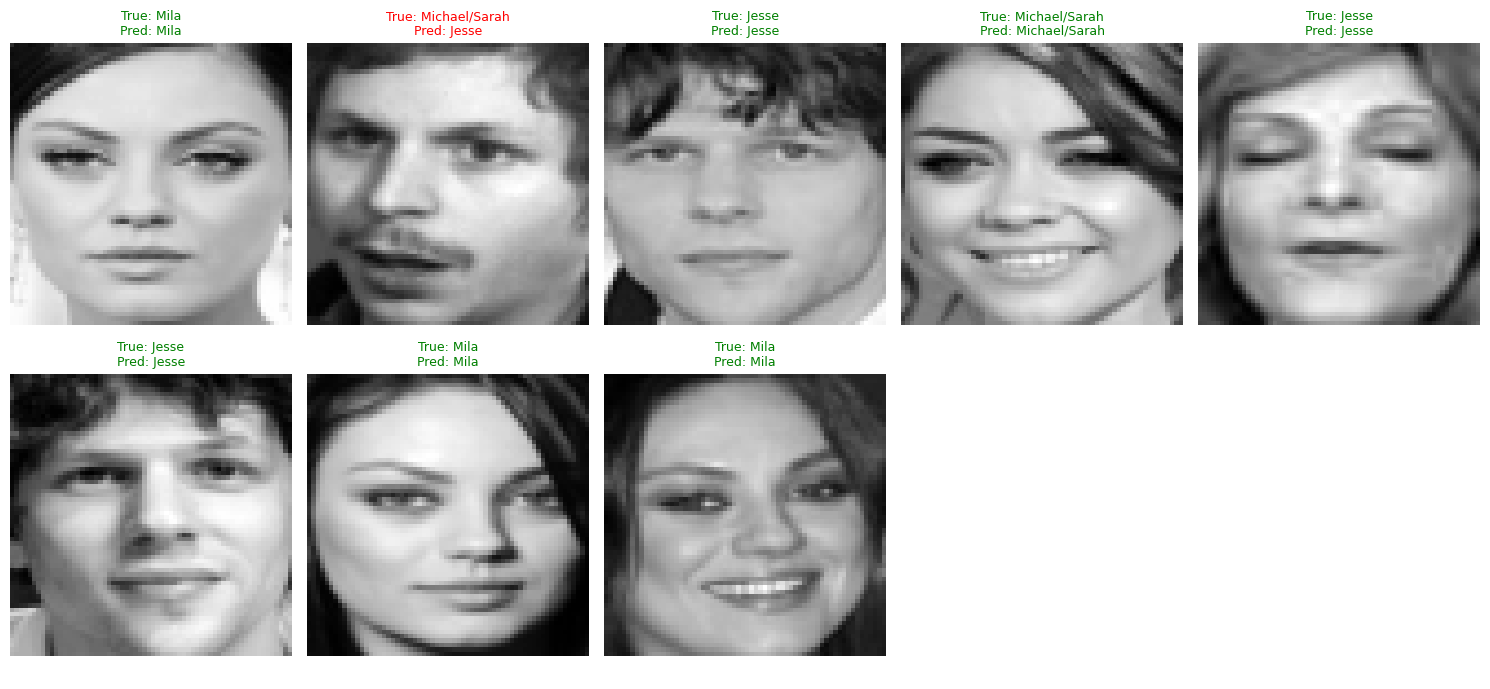

In [38]:
plot_validation_images(
    X_val_images=X_val_gray,
    y_val_true=y_val,
    y_val_pred=y_val_pred,
    class_names=['Michael/Sarah', 'Jesse', 'Mila']
)

In [34]:
test_y_hog = best_model.predict(test_hog_features)

print(f"\nTest prediction distribution:")
unique, counts = np.unique(test_y_hog, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls} ({class_names[cls]}): {cnt} images ({cnt/len(test_y_hog)*100:.1f}%)")


Test prediction distribution:
  Class 0 (Michael/Sarah): 495 images (27.3%)
  Class 1 (Jesse): 626 images (34.5%)
  Class 2 (Mila): 695 images (38.3%)


# 5. Publishing best results

In [ ]:
submission = test.copy().drop('img', axis = 1)
submission['class'] = test_y_star

submission

In [ ]:
submission.to_csv('submission.csv')

# 6. Discussion
...

In summary we contributed the following: 
* 
